In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset_Day6.csv')
df.head()

,Area,BHK,Bathroom,Furnishing,Parking,Price,Status,Transaction,Type
0,800.0,3,2.0,Semi-Furnished,1.0,6500000,Ready_to_move,New_Property,Builder_Floor
1,750.0,2,2.0,Semi-Furnished,1.0,5000000,Ready_to_move,New_Property,Apartment
2,950.0,2,2.0,Furnished,1.0,15500000,Ready_to_move,Resale,Apartment
3,600.0,2,2.0,Semi-Furnished,1.0,4200000,Ready_to_move,Resale,Builder_Floor
4,650.0,2,2.0,Semi-Furnished,1.0,6200000,Ready_to_move,New_Property,Builder_Floor


In [3]:
cols_with_missing = [col for col in df.columns if df[col].isna().sum() >0] 
cols_with_missing

['Bathroom', 'Furnishing', 'Parking', 'Type']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Parking      1226 non-null   float64
 5   Price        1259 non-null   int64  
 6   Status       1259 non-null   object 
 7   Transaction  1259 non-null   object 
 8   Type         1254 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 88.7+ KB


Here we can observe:

Bathroom and Parking have float64 datatype, so we'll use median to treat the missing values
Furnishing and Type have object datatype, so we'll use mode to treat the missing values

In [5]:
#treating Bathroom and Parking data
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

df = df.fillna(median_value)

['Area', 'BHK', 'Bathroom', 'Parking', 'Price']
Area            1200.0
BHK                3.0
Bathroom           2.0
Parking            1.0
Price       14200000.0
dtype: float64


In [6]:
#treating Furnishing and Type data
object_col = []
for col in df.columns:
    if df[col].dtype == 'object':
        object_col.append(col)

print(object_col)

mode_value = df[object_col].mode().iloc[0]
print(mode_value)

df = df.fillna(mode_value)

['Furnishing', 'Status', 'Transaction', 'Type']
Furnishing     Semi-Furnished
Status          Ready_to_move
Transaction            Resale
Type            Builder_Floor
Name: 0, dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1259 non-null   float64
 3   Furnishing   1259 non-null   object 
 4   Parking      1259 non-null   float64
 5   Price        1259 non-null   int64  
 6   Status       1259 non-null   object 
 7   Transaction  1259 non-null   object 
 8   Type         1259 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 88.7+ KB


In [8]:
# remove outliers
outlier_data = pd.DataFrame()

z_score = (df['Price']-df['Price'].mean())/df['Price'].std()
outlier_data['Price']=df['Price'][(z_score>3)|(z_score<-3)]
    
display(len(outlier_data)/len(df)*100)

data_noOutlier = df.drop(outlier_data.index, axis = 0)
data_noOutlier.info()

1.7474185861795075

<class 'pandas.core.frame.DataFrame'>
Index: 1237 entries, 0 to 1258
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1237 non-null   float64
 1   BHK          1237 non-null   int64  
 2   Bathroom     1237 non-null   float64
 3   Furnishing   1237 non-null   object 
 4   Parking      1237 non-null   float64
 5   Price        1237 non-null   int64  
 6   Status       1237 non-null   object 
 7   Transaction  1237 non-null   object 
 8   Type         1237 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 96.6+ KB


In [9]:
#2.	Use One Hot Encoding to encode all character variables.
df1 = pd.get_dummies(data_noOutlier)
df1.head()

,Area,BHK,Bathroom,Parking,Price,Furnishing_Furnished,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Status_Almost_ready,Status_Ready_to_move,Transaction_New_Property,Transaction_Resale,Type_Apartment,Type_Builder_Floor
0,800.0,3,2.0,1.0,6500000,False,True,False,False,True,True,False,False,True
1,750.0,2,2.0,1.0,5000000,False,True,False,False,True,True,False,True,False
2,950.0,2,2.0,1.0,15500000,True,False,False,False,True,False,True,True,False
3,600.0,2,2.0,1.0,4200000,False,True,False,False,True,False,True,False,True
4,650.0,2,2.0,1.0,6200000,False,True,False,False,True,True,False,False,True


,Area,BHK,Bathroom,Parking,Price,Furnishing_Furnished,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Status_Almost_ready,Status_Ready_to_move,Transaction_New_Property,Transaction_Resale,Type_Apartment,Type_Builder_Floor
Area,1.000000,0.414916,0.484588,-0.014162,0.507810,-0.039654,0.079601,-0.056244,0.140919,-0.140919,0.082310,-0.082310,-0.088530,0.088530
BHK,0.414916,1.000000,0.762739,-0.073721,0.603833,0.056780,0.088293,-0.141181,0.087155,-0.087155,0.113218,-0.113218,-0.110403,0.110403
Bathroom,0.484588,0.762739,1.000000,-0.036530,0.770980,-0.048150,0.116012,-0.089513,0.119056,-0.119056,0.171496,-0.171496,-0.136588,0.136588
Parking,-0.014162,-0.073721,-0.036530,1.000000,-0.013580,-0.030559,-0.049353,0.077993,-0.017093,0.017093,-0.035988,0.035988,0.075915,-0.075915
Price,0.507810,0.603833,0.770980,-0.013580,1.000000,-0.062013,0.099591,-0.060673,0.164166,-0.164166,0.186421,-0.186421,-0.118933,0.118933
Furnishing_Furnished,-0.039654,0.056780,-0.048150,-0.030559,-0.062013,1.000000,-0.474241,-0.262137,-0.000959,0.000959,-0.133973,0.133973,0.079047,-0.079047
Furnishing_Semi-Furnished,0.079601,0.088293,0.116012,-0.049353,0.099591,-0.474241,1.000000,-0.725292,-0.050892,0.050892,0.151759,-0.151759,-0.106394,0.106394
Furnishing_Unfurnished,-0.056244,-0.141181,-0.089513,0.077993,-0.060673,-0.262137,-0.725292,1.000000,0.056534,-0.056534,-0.061586,0.061586,0.054810,-0.054810
Status_Almost_ready,0.140919,0.087155,0.119056,-0.017093,0.164166,-0.000959,-0.050892,0.056534,1.000000,-1.000000,0.250293,-0.250293,0.030426,-0.030426
Status_Ready_to_move,-0.140919,-0.087155,-0.119056,0.017093,-0.164166,0.000959,0.050892,-0.056534,-1.000000,1.000000,-0.250293,0.250293,-0.030426,0.030426


<Axes: >

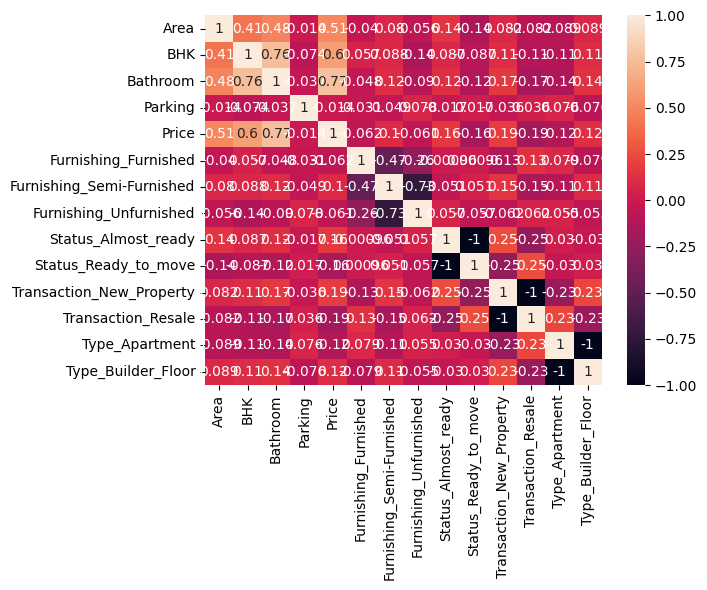

In [10]:
# check for multicollinearity using pairwise correlation coefficient
display(df1.corr())
display(sns.heatmap(data=df1.corr(), annot=True))

In [11]:
new_df1=df1.drop(['Bathroom','Status_Almost_ready','Transaction_New_Property','Type_Apartment'],axis=1)
new_df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1237 entries, 0 to 1258
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Area                       1237 non-null   float64
 1   BHK                        1237 non-null   int64  
 2   Parking                    1237 non-null   float64
 3   Price                      1237 non-null   int64  
 4   Furnishing_Furnished       1237 non-null   bool   
 5   Furnishing_Semi-Furnished  1237 non-null   bool   
 6   Furnishing_Unfurnished     1237 non-null   bool   
 7   Status_Ready_to_move       1237 non-null   bool   
 8   Transaction_Resale         1237 non-null   bool   
 9   Type_Builder_Floor         1237 non-null   bool   
dtypes: bool(6), float64(2), int64(2)
memory usage: 55.6 KB


In [12]:
X = df1.drop("Price",axis = 1)
y = df1["Price"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [13]:
# Multiple Linear regression model fitting
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train,y_train)
#predict the outcomes

y_pred = lm.predict(X_test)


coefficients = pd.DataFrame(lm.coef_,X.columns)
coefficients.columns = ['coefficients']
display(coefficients)

print("intercept is {}".format(lm.intercept_))

from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

r2 = r2_score(y_test,y_pred) 
mae = mean_absolute_error(y_test,y_pred)

print("The model performance for training set")
print("--------------------------------------")
print('Mean Absolute Error is {}'.format(mae))
print('R2 score is {}%'.format(r2*100))
print("\n")

mse = mean_squared_error(y_test,y_pred)
print('Mean Square Error is {}'.format(mse))

,coefficients
Area,1.852560e+03
BHK,3.633990e+05
Bathroom,1.228837e+07
Parking,4.085738e+04
Furnishing_Furnished,-5.329210e+05
Furnishing_Semi-Furnished,4.734201e+05
Furnishing_Unfurnished,5.950088e+04
Status_Almost_ready,2.522652e+06
Status_Ready_to_move,-2.522652e+06
Transaction_New_Property,9.667979e+05


intercept is -13065952.14857873
The model performance for training set
--------------------------------------
Mean Absolute Error is 7945898.881733519
R2 score is 59.41238277045573%


Mean Square Error is 115163759560072.22


In [14]:
#4.	Repeat the above process for a Ridge Regression and show from the new evaluation metrics if there is any improvement in the model performance?
from sklearn.linear_model import Ridge

alpha = np.linspace(1e-35,1e-25,100)

print(alpha)

best_alpha = 0
best_mse = mse
for param in alpha:
    ridgeModel=Ridge(alpha = param)
    ridgeModel.fit(X_train, y_train)
    
    y_pred = ridgeModel.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    
    print("alpha = {}".format(param))
    print("mse for above alpha = {}".format(mse))
    print("======================================")
    
    if(mse < best_mse):
        best_mse = mse
        best_alpha = param

print("Best value of alpha/lambda = {}".format(best_alpha))
print("MSE for this alpha/lambda = {}".format(best_mse))


[1.00000000e-35 1.01010102e-27 2.02020203e-27 3.03030304e-27
 4.04040405e-27 5.05050506e-27 6.06060607e-27 7.07070708e-27
 8.08080809e-27 9.09090910e-27 1.01010101e-26 1.11111111e-26
 1.21212121e-26 1.31313131e-26 1.41414141e-26 1.51515152e-26
 1.61616162e-26 1.71717172e-26 1.81818182e-26 1.91919192e-26
 2.02020202e-26 2.12121212e-26 2.22222222e-26 2.32323232e-26
 2.42424242e-26 2.52525253e-26 2.62626263e-26 2.72727273e-26
 2.82828283e-26 2.92929293e-26 3.03030303e-26 3.13131313e-26
 3.23232323e-26 3.33333333e-26 3.43434343e-26 3.53535354e-26
 3.63636364e-26 3.73737374e-26 3.83838384e-26 3.93939394e-26
 4.04040404e-26 4.14141414e-26 4.24242424e-26 4.34343434e-26
 4.44444445e-26 4.54545455e-26 4.64646465e-26 4.74747475e-26
 4.84848485e-26 4.94949495e-26 5.05050505e-26 5.15151515e-26
 5.25252525e-26 5.35353535e-26 5.45454546e-26 5.55555556e-26
 5.65656566e-26 5.75757576e-26 5.85858586e-26 5.95959596e-26
 6.06060606e-26 6.16161616e-26 6.26262626e-26 6.36363636e-26
 6.46464646e-26 6.565656

In [15]:
#5.	Also do above for Lasso Regression (HW. research code online)
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

alpha = np.linspace(1e-5, 1, 100)

print(alpha)

best_alpha = 0
best_mse = float('inf')

for param in alpha:
    lassoModel = Lasso(alpha=param, max_iter=10000)
    lassoModel.fit(X_train, y_train)
    
    y_pred = lassoModel.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    print("alpha = {}".format(param))
    print("MSE for above alpha = {}".format(mse))
    print("======================================")
    
    if mse < best_mse:
        best_mse = mse
        best_alpha = param

print("\nBest value of alpha/lambda = {}".format(best_alpha))
print("MSE for this alpha/lambda = {}".format(best_mse))

[1.00000000e-05 1.01109091e-02 2.02118182e-02 3.03127273e-02
 4.04136364e-02 5.05145455e-02 6.06154545e-02 7.07163636e-02
 8.08172727e-02 9.09181818e-02 1.01019091e-01 1.11120000e-01
 1.21220909e-01 1.31321818e-01 1.41422727e-01 1.51523636e-01
 1.61624545e-01 1.71725455e-01 1.81826364e-01 1.91927273e-01
 2.02028182e-01 2.12129091e-01 2.22230000e-01 2.32330909e-01
 2.42431818e-01 2.52532727e-01 2.62633636e-01 2.72734545e-01
 2.82835455e-01 2.92936364e-01 3.03037273e-01 3.13138182e-01
 3.23239091e-01 3.33340000e-01 3.43440909e-01 3.53541818e-01
 3.63642727e-01 3.73743636e-01 3.83844545e-01 3.93945455e-01
 4.04046364e-01 4.14147273e-01 4.24248182e-01 4.34349091e-01
 4.44450000e-01 4.54550909e-01 4.64651818e-01 4.74752727e-01
 4.84853636e-01 4.94954545e-01 5.05055455e-01 5.15156364e-01
 5.25257273e-01 5.35358182e-01 5.45459091e-01 5.55560000e-01
 5.65660909e-01 5.75761818e-01 5.85862727e-01 5.95963636e-01
 6.06064545e-01 6.16165455e-01 6.26266364e-01 6.36367273e-01
 6.46468182e-01 6.565690

C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(


alpha = 0.01011090909090909
MSE for above alpha = 115163759310111.6
alpha = 0.02021181818181818
MSE for above alpha = 115163759060398.64


C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(


alpha = 0.030312727272727272
MSE for above alpha = 115163758810685.66
alpha = 0.04041363636363637
MSE for above alpha = 115163758560972.53


...

C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(


alpha = 0.9494954545454545
MSE for above alpha = 115163736086818.92
alpha = 0.9595963636363636
MSE for above alpha = 115163735837105.73
alpha = 0.9696972727272727
MSE for above alpha = 115163735587393.52


C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

alpha = 0.9797981818181818
MSE for above alpha = 115163735337681.36
alpha = 0.9898990909090909
MSE for above alpha = 115163735087968.94
alpha = 1.0
MSE for above alpha = 115163734838256.4

Best value of alpha/lambda = 1.0
MSE for this alpha/lambda = 115163734838256.4


C:\Users\archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.784e+15, tolerance: 3.370e+13
  model = cd_fast.enet_coordinate_descent(
